# RPM Calculation from `pg_rpm` Pulse Signal

This notebook demonstrates how to calculate the actual motor rotational speed (RPM)
from the `pg_rpm` pulse signal column in the OpenBLDCData dataset.

**Key fact:** The motor driver outputs **6 pulses per one full mechanical revolution**.
By counting pulse edges (rising transitions from 0 → 1) within a time window,
we can estimate the instantaneous RPM.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [23]:
df = pd.read_csv('../data/analize_healthy10_1000rpm_64mA_bat.csv')

# t_us is in microseconds — convert to seconds
df['t_s'] = df['t_us'] * 1e-6

print(f"Samples: {len(df)}")
print(f"Duration: {df['t_s'].iloc[-1]:.2f} s")

Samples: 262389
Duration: 262.39 s


## Detect rising edges (0 → 1 transitions)

A rising edge marks one pulse from the motor driver.
6 pulses = 1 full mechanical revolution.

In [ ]:
PULSES_PER_REV = 6
rising_edge = (df['pg_rpm'].shift(1) == 0) & (df['pg_rpm'] == 1)
pulse_times = df.loc[rising_edge, 't_s'].values

print(f"Total pulses detected: {len(pulse_times)}")
print(f"Total revolutions: {len(pulse_times) / PULSES_PER_RE:.1f}")

Total pulses detected: 26130
Total revolutions: 4355.0


## Calculate RPM from consecutive pulses

Time between 6 consecutive pulses = time per revolution.

$$\text{RPM} = \frac{60}{\Delta t_{6\,\text{pulses}}}$$

where $\Delta t_{6\,\text{pulses}}$ is the time interval (in seconds) spanning 6 pulse edges.

In [25]:

if len(pulse_times) > PULSES_PER_REV:
    rev_dt = pulse_times[PULSES_PER_REV:] - pulse_times[:-PULSES_PER_REV]
    rpm_values = 60.0 / rev_dt
    rpm_times  = pulse_times[PULSES_PER_REV:]  # timestamp at the end of each revolution

    print(f"Mean RPM : {rpm_values.mean():.1f}")
    print(f"Std  RPM : {rpm_values.std():.1f}")
    print(f"Min  RPM : {rpm_values.min():.1f}")
    print(f"Max  RPM : {rpm_values.max():.1f}")

Mean RPM : 995.9
Std  RPM : 7.1
Min  RPM : 982.5
Max  RPM : 1001.2


## Plot RPM stability over time

This plot shows the temporal evolution of the instantaneous RPM estimated from pulse timing.
A practical baseline for "normal" jitter can be derived from timing resolution at a sampling rate of $f_s=1\,\mathrm{kHz}$, i.e. $T_s=1\,\mathrm{ms}$.

Using 6 pulses per revolution, the revolution period estimate is
$$T_{\mathrm{rev}} = t_{k+6}-t_k, \qquad \mathrm{RPM}=\frac{60}{T_{\mathrm{rev}}}.$$

If each timestamp is quantized to the sampling grid, then a conservative timing uncertainty is
$$|\delta T_{\mathrm{rev}}|_{\max}\approx T_s, \qquad \sigma_{T_{\mathrm{rev}}}\approx \frac{T_s}{\sqrt{2}}.$$

First-order uncertainty propagation gives
$$\delta\mathrm{RPM} \approx \left|\frac{d}{dT}\left(\frac{60}{T}\right)\right|\delta T_{\mathrm{rev}} = \frac{60}{T_{\mathrm{rev}}^2}\,\delta T_{\mathrm{rev}} = \frac{\mathrm{RPM}^2}{60}\,\delta T_{\mathrm{rev}}.$$

At $\mathrm{RPM}\approx1000$ and $T_s=1\,\mathrm{ms}$:
- RMS uncertainty: $\sigma_{\mathrm{RPM}}\approx \frac{1000^2}{60}\cdot\frac{0.001}{\sqrt{2}}\approx 11.8\,\mathrm{RPM}$
- Worst-case bound: $|\delta\mathrm{RPM}|_{\max}\approx \frac{1000^2}{60}\cdot0.001\approx 16.7\,\mathrm{RPM}$

Therefore, short-term fluctuations on the order of roughly $\pm(10\text{ to }20)$ RPM around the nominal value are mathematically expected from sampling-time quantization/jitter alone, even without true mechanical speed changes.

### Consistency with observed statistics

Observed values: Mean $=995.9$, Std $=7.1$, Min $=982.5$, Max $=1001.2$ RPM.

Interpretation:
- The standard deviation ($7.1$ RPM) is below the theoretical RMS jitter level ($\approx 11.8$ RPM).
- Relative to the mean, deviations are $-13.4$ RPM (min) and $+5.3$ RPM (max), both within the conservative worst-case bound ($\pm 16.7$ RPM).
- Relative to the 1000 RPM target, the mean offset is $-4.1$ RPM, which is small and consistent with expected measurement/control bias.

Conclusion: the observed RPM spread is consistent with the theoretical uncertainty expected from 1 kHz timing quantization and 6-pulse-per-revolution estimation.

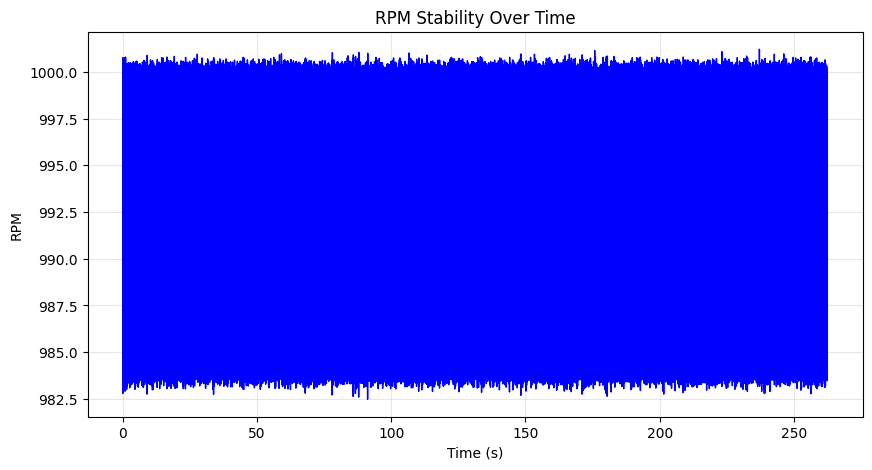

In [26]:
if 'rpm_times' not in globals() or 'rpm_values' not in globals():
    raise NameError("rpm_times and rpm_values are not defined. Run the previous RPM calculation cell first.")

plt.figure(figsize=(10, 5))
plt.plot(rpm_times, rpm_values, linestyle='-', color='blue', linewidth=1)
plt.title('RPM Stability Over Time')
plt.xlabel('Time (s)')
plt.ylabel('RPM')
plt.grid(True, alpha=0.3)
plt.show()

## Summary

| Step | Description |
| --- | --- |
| 1 | Read `t_us` (timestamp in µs) and `pg_rpm` (0/1 pulse) columns |
| 2 | Detect rising edges (0 → 1 transitions) to find pulse timestamps |
| 3 | Group 6 consecutive pulses = 1 mechanical revolution |
| 4 | $\text{RPM} = 60 / \Delta t_{\text{revolution}}$ |

